# Uber App Recovery Rate OSINT — Final Submission Notebook

This notebook is organized as a submission-ready, reproducible pipeline for the paper.

## Pipeline
1. Environment and reproducibility setup
2. Data loading and preprocessing
3. Negative-review filtering (`rating <= 2`)
4. Zero-shot complaint classification
5. Sentence embeddings + cosine similarity + Louvain community detection
6. Version-level feature engineering
7. Recovery-speed target construction
8. Baseline and predictive modeling
9. Interpretation with feature importance and SHAP

## Reproducibility
- Set `REBUILD_PIPELINE = True` to recompute all expensive steps from scratch.
- Set `REBUILD_PIPELINE = False` to reuse cached JSON / NPY / Parquet files.
- Set `FORCE_REBUILD_CACHE = False` to use the existing cache.
- Set `FORCE_REBUILD_CACHE = True` to rebuild from scratch.
- This notebook intentionally does **not** use ChromaDB, because it is not required by the course workflow and created dependency conflicts with SHAP.


In [1]:
# =========================
# REPRODUCIBILITY / PATH SETUP
# =========================

REBUILD_PIPELINE = False
FORCE_REBUILD_CACHE = False
SEED = 42

import os, random, numpy as np

np.random.seed(SEED)
random.seed(SEED)

BASE_PATH = os.environ.get("OSINT_BASE_PATH", "/content/drive/MyDrive/OSINT")
DATA_DIR = os.path.join(BASE_PATH, "data")
CACHE_DIR = os.path.join(BASE_PATH, "cache")
MODEL_DIR = os.path.join(BASE_PATH, "models")
LIB_DIR = os.path.join(BASE_PATH, "libs")

print("REBUILD_PIPELINE =", REBUILD_PIPELINE)
print("FORCE_REBUILD_CACHE =", FORCE_REBUILD_CACHE)
print("BASE_PATH =", BASE_PATH)
print("CACHE_DIR =", CACHE_DIR)


REBUILD_PIPELINE = False
FORCE_REBUILD_CACHE = False
BASE_PATH = /content/drive/MyDrive/OSINT
CACHE_DIR = /content/drive/MyDrive/OSINT/cache


In [2]:
# =========================
# ENVIRONMENT SETUP
# =========================
# ChromaDB is intentionally NOT installed here.
# Checkpointing is handled through JSON / NPY / Parquet cache files.

!pip install -q \
  "sentence-transformers>=3,<4" \
  "transformers>=4.41,<5" \
  "datasets>=2,<4" \
  "accelerate>=0.30,<2" \
  "umap-learn>=0.5" \
  "hdbscan>=0.8" \
  "python-louvain>=0.16" \
  "shap"

import sys
import numpy as np
import pandas as pd
import sklearn
import shap
import transformers
import sentence_transformers

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("transformers:", transformers.__version__)
print("sentence-transformers:", sentence_transformers.__version__)
print("shap:", shap.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 20.7 MB/s eta 0:00:00
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1
transformers: 4.57.6
sentence-transformers: 3.4.1
shap: 0.51.0


In [3]:
# Mount Google Drive when running in Colab
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print("Drive mount skipped:", e)


Mounted at /content/drive


In [4]:
import pandas as pd

CSV_PATH = os.path.join(DATA_DIR, "cleaned_filtered_reviews.csv")
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
display(df.head(2))


Shape: (44309, 10)


,Srno,review_id,pseudo_author_id,author_name,review_text,review_rating,review_likes,author_app_version,review_timestamp,clean_text
0,700377,aad4381e-1e42-4c7b-9835-33811af2450d,4.638530e+20,A Google user,make it simple. to order a uber ride..Far too ...,1,1,4.267.10003,24-06-2019 19:18,make it simple. to order a uber ride..Far too ...
1,822186,6c278328-b7ce-4779-96e8-46d38b9c39e4,2.011700e+20,Ce***ee,Not good. The app doesn't have a sign on optio...,1,3,4.315.10004,13-05-2020 04:56,Not good. The app doesn t have a sign on optio...


## Optional local LLM loading

This notebook keeps the same `llm = Llama(...)` path used in the project.  
If the LLM is not available in the current runtime, previously cached zero-shot results can still be loaded and used.

In [5]:
import os
import sys

LLM_AVAILABLE = False
llm = None

try:
    sys.path.append("/content/drive/MyDrive/OSINT/libs")
    from llama_cpp import Llama

    MODEL_PATH = "/content/drive/MyDrive/OSINT/models/Mistral-Nemo-Instruct-2407-Q5_K_M.gguf"

    llm = Llama(
        model_path=MODEL_PATH,
        n_gpu_layers=-1,
        n_ctx=4096,
        n_batch=512,
        use_mmap=True,
        use_mlock=True,
        verbose=False
    )

    LLM_AVAILABLE = True
    print("Model loaded successfully")

except Exception as e:
    print("LLM not available in this runtime.")
    print("Reason:", str(e))
    print("Continuing without loading llama.cpp. Cached classification results can still be used.")

llama_context: n_ctx_per_seq (4096) < n_ctx_train (1024000) -- the full capacity of the model will not be utilized


Model loaded successfully


## Research Question Pipeline: Zero-shot themes → version metrics → recovery speed → prediction

This section implements the research-question pipeline:

1. **Zero-shot classify** negative reviews into complaint themes (using the same `llm = Llama(...)` approach as earlier)
2. Aggregate **version complaint metrics** (theme shares, counts, confidence)
3. Compute **recovery speed** of the **next** version from review ratings over time
4. Train a **prediction model** to predict recovery days from the previous version's complaint profile

> Designed to be scalable: we classify only a capped number of the most informative negative reviews per version and cache results to disk.

In [6]:

# Column detection (robust to small naming differences)
import pandas as pd
import numpy as np
import re


def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    return None

RATING_COL  = pick_col(df, ["review_rating", "review_rat", "rating", "stars"])
LIKES_COL   = pick_col(df, ["review_likes", "review_lik", "likes", "thumbs_up"])
TEXT_COL    = pick_col(df, ["clean_text", "review_text", "review_te", "text"])
RAW_VERSION_COL = pick_col(df, ["author_app_version", "author_ap", "app_version", "version"])
TIME_COL    = pick_col(df, ["review_timestamp", "review_time", "review_ti", "date", "review_date", "timestamp", "created_at"])
VERSION_COL = "version_norm"

print("Detected columns:")
print("  TEXT_COL       =", TEXT_COL)
print("  RATING_COL     =", RATING_COL)
print("  LIKES_COL      =", LIKES_COL)
print("  RAW_VERSION_COL=", RAW_VERSION_COL)
print("  TIME_COL       =", TIME_COL)
print("  VERSION_COL    =", VERSION_COL)

assert TEXT_COL is not None, "Could not find text column (e.g., clean_text)."
assert RATING_COL is not None, "Could not find rating column."
assert RAW_VERSION_COL is not None, "Could not find app version column."

# Full working dataset
work_full = df.copy()
work_full = work_full[work_full[TEXT_COL].notna()].copy()
work_full[TEXT_COL] = work_full[TEXT_COL].astype(str)

work_full[RATING_COL] = pd.to_numeric(work_full[RATING_COL], errors="coerce")
work_full = work_full[work_full[RATING_COL].notna()].copy()
work_full[RATING_COL] = work_full[RATING_COL].astype(int)

if LIKES_COL is not None:
    work_full[LIKES_COL] = pd.to_numeric(work_full[LIKES_COL], errors="coerce").fillna(0).astype(int)
else:
    work_full["__likes__"] = 0
    LIKES_COL = "__likes__"

# Normalize version to the first major.minor pattern, fallback to a cleaned numeric token
version_str = work_full[RAW_VERSION_COL].astype(str).str.strip()
version_norm = version_str.str.extract(r'(\d+\.\d+)')[0]
version_norm = version_norm.fillna(version_str.str.extract(r'(\d+(?:\.\d+)?)')[0])
work_full[VERSION_COL] = version_norm
work_full = work_full[work_full[VERSION_COL].notna()].copy()
work_full[VERSION_COL] = pd.to_numeric(work_full[VERSION_COL], errors='coerce')
work_full = work_full[work_full[VERSION_COL].notna()].copy()

if TIME_COL is not None:
    work_full[TIME_COL] = pd.to_datetime(
        work_full[TIME_COL],
        format="%d-%m-%Y %H:%M",
        errors="coerce"
    )
    # fallback for mixed formats
    mask_bad = work_full[TIME_COL].isna()
    if mask_bad.any():
        work_full.loc[mask_bad, TIME_COL] = pd.to_datetime(
            work_full.loc[mask_bad, TIME_COL].astype(str),
            format='mixed', dayfirst=True, errors='coerce'
        )
else:
    print("WARNING: No timestamp column detected. Recovery speed will not be computable without dates.")

# Complaint-analysis subset (negative only) will be derived later from work_full
work = work_full.copy()

print("Working full-data shape:", work_full.shape)
display(work_full[[VERSION_COL, RATING_COL, LIKES_COL, TEXT_COL] + ([TIME_COL] if TIME_COL else [])].head())


Detected columns:
  TEXT_COL       = clean_text
  RATING_COL     = review_rating
  LIKES_COL      = review_likes
  RAW_VERSION_COL= author_app_version
  TIME_COL       = review_timestamp
  VERSION_COL    = version_norm
Working full-data shape: (41629, 11)


,version_norm,review_rating,review_likes,clean_text,review_timestamp
0,4.267,1,1,make it simple. to order a uber ride..Far too ...,2019-06-24 19:18:00
1,4.315,1,3,Not good. The app doesn t have a sign on optio...,2020-05-13 04:56:00
2,3.143,1,51,The app and idea itself is a great resource fo...,2017-03-10 16:27:00
3,4.345,1,82,It has already happened to me several times th...,2020-12-09 06:08:00
4,4.252,1,5,I have to wait for at my pickup point for more...,2019-03-10 08:50:00


### 1) Zero-shot classification of negative reviews into complaint themes

We classify only **negative reviews** (rating ≤ 2) and cap the number per version to keep runtime reasonable.

- prioritize reviews with higher **likes** and longer text
- **cache** results to disk so you can resume without re-running everything

In [7]:
from collections import defaultdict
import os, json, hashlib, re, time
import pandas as pd
import numpy as np

# Runtime controls
NEGATIVE_MAX_RATING = 2   # paper threshold: rating <= 2 only
MIN_TEXT_LEN = 30
MIN_LIKES = 1

# Keep only versions that have enough negative reviews after filtering
MIN_REVIEWS_PER_VERSION = 30

# Cap classified reviews per version to control runtime
MAX_REVIEWS_PER_VERSION = 15

# Complaint theme label set
THEME_LABELS = [
    "App crash / freezing",
    "Login / account issues",
    "Payment / billing problems",
    "GPS / maps / location issues",
    "Driver cancellation / no-show",
    "Pickup / dropoff location issues",
    "Pricing / surge / fare disputes",
    "Customer support problems",
    "Promo / coupons not working",
    "Other"
]

ROOT_DIR = BASE_PATH
CACHE_DIR = os.path.join(ROOT_DIR, "cache")
os.makedirs(CACHE_DIR, exist_ok=True)

CACHE_PATH = os.path.join(CACHE_DIR, "zero_shot_theme_cache.jsonl")
THEME_PARQUET_PATH = os.path.join(CACHE_DIR, "zero_shot_theme_cache.parquet")

# Normalize version for the modeling pipeline
work = work.copy()
work["version_norm"] = work[VERSION_COL].astype(str).str.extract(r'^(\d+\.\d+)')
work["version_norm"] = work["version_norm"].fillna("unknown")
VERSION_COL = "version_norm"

# Load existing cache unless a true rebuild is requested
cache = {}
if FORCE_REBUILD_CACHE:
    print("FORCE_REBUILD_CACHE=True -> ignoring existing zero-shot cache.")
else:
    if os.path.exists(CACHE_PATH):
        with open(CACHE_PATH, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    obj = json.loads(line)
                    cache[obj["key"]] = obj
                except Exception:
                    pass

print("Cache entries loaded:", len(cache))

def review_key(version, text):
    version = str(version).strip()
    text = str(text).strip()
    h = hashlib.md5(text.encode("utf-8")).hexdigest()
    return f"{version}::{h}"

def zero_shot_theme(review_text):
    review_text = str(review_text).strip()[:2000]
    labels_str = "\n".join([f"- {lab}" for lab in THEME_LABELS])

    prompt = (
        "You are analyzing negative Uber app reviews.\n\n"
        "Task: Classify the review into exactly ONE complaint theme from the list below.\n"
        "Then provide a confidence score between 0 and 1.\n\n"
        f"Themes:\n{labels_str}\n\n"
        "Return STRICT JSON only, in this exact format:\n"
        '{"label": "<one_theme_from_list>", "confidence": <number_between_0_and_1>}\n\n'
        f"Review:\n{review_text}\n"
    )

    out = llm(prompt, max_tokens=80, temperature=0)
    txt = out["choices"][0]["text"].strip()

    try:
        m = re.search(r'\{.*\}', txt, flags=re.S)
        if not m:
            raise ValueError("No JSON object found.")
        obj = json.loads(m.group(0))
        label = str(obj.get("label", "Other")).strip()
        conf = float(obj.get("confidence", 0.0))
        if label not in THEME_LABELS:
            label = "Other"
        conf = max(0.0, min(1.0, conf))
        return label, conf
    except Exception:
        return "error", 0.0

# Filter reviews for classification
neg = work[
    (work[RATING_COL] <= NEGATIVE_MAX_RATING) &
    (work[TEXT_COL].str.len() >= MIN_TEXT_LEN) &
    (work[LIKES_COL] >= MIN_LIKES)
].copy()

# versions with enough filtered negatives
valid_versions = (
    neg.groupby(VERSION_COL)
       .size()
       .loc[lambda s: s >= MIN_REVIEWS_PER_VERSION]
       .index
)

neg = neg[neg[VERSION_COL].isin(valid_versions)].copy()

# rank within version: more liked and longer first
neg["__text_len__"] = neg[TEXT_COL].str.len()
neg = neg.sort_values([VERSION_COL, LIKES_COL, "__text_len__"], ascending=[True, False, False])

# keep top K reviews per version
neg_top = neg.groupby(VERSION_COL).head(MAX_REVIEWS_PER_VERSION).copy()

# build keys and collect only uncached rows
to_classify = []
for _, row in neg_top.iterrows():
    version = row[VERSION_COL]
    text = row[TEXT_COL]
    k = review_key(version, text)
    if k not in cache:
        to_classify.append((version, text, k))

print("Versions kept:", len(valid_versions))
print("Candidate reviews after cap:", len(neg_top))
print("Already cached:", len(cache))
print("Still to classify:", len(to_classify))

Cache entries loaded: 5739
Versions kept: 301
Candidate reviews after cap: 4515
Already cached: 5739
Still to classify: 0


In [8]:
import time

if len(to_classify) > 0 and llm is None:
    raise RuntimeError(
        "LLM is not available in this runtime and new reviews still need classification. "
        "Either enable the local model or reuse an already-complete cache."
    )

new_rows = 0
start_time = time.time()
total = len(to_classify)

file_mode = "w" if FORCE_REBUILD_CACHE else "a"

with open(CACHE_PATH, file_mode, encoding="utf-8") as f:
    for i, (version, text, k) in enumerate(to_classify, start=1):
        label, conf = zero_shot_theme(text)

        obj = {
            "key": k,
            "version": version,
            "label": label,
            "confidence": conf
        }

        # Skip persisting failed classifications as final cache entries
        if label != "error":
            f.write(json.dumps(obj, ensure_ascii=False) + "\n")
            f.flush()
            cache[k] = obj
            new_rows += 1

        if i % 20 == 0 or i == total:
            elapsed = time.time() - start_time
            rate = i / elapsed if elapsed > 0 else 0
            eta = (total - i) / rate if rate > 0 else 0

            print(
                f"[{i}/{total}] "
                f"new={new_rows}, "
                f"cache={len(cache)}, "
                f"speed={rate:.2f} reviews/sec, "
                f"elapsed={elapsed/60:.1f} min, "
                f"eta={eta/60:.1f} min"
            )

print("Done.")
print("Newly classified this run:", new_rows)
print("Total cache size:", len(cache))

theme_df = pd.DataFrame([v for v in cache.values() if v.get("label") != "error"]).copy()
theme_df.to_parquet(THEME_PARQUET_PATH, index=False)

print("theme_df shape:", theme_df.shape)
print("Saved checkpoint:", THEME_PARQUET_PATH)
display(theme_df.head())

Done.
Newly classified this run: 0
Total cache size: 5739
theme_df shape: (5336, 4)
Saved checkpoint: /content/drive/MyDrive/OSINT/cache/zero_shot_theme_cache.parquet


,key,version,label,confidence
0,1.0::91782768c6fb86cc4b835319e78166a1,1.0,Other,0.00
1,1.0::a64e2e2e27c98dd2f11e3bf0b808f27a,1.0,Pricing / surge / fare disputes,0.95
2,1.0::f42ae0ea69a3ebe63fdcfc1d56aa4ed9,1.0,Other,0.00
3,1.0::06eebb9c0aa305e8635f9389d3bee7ca,1.0,Other,0.95
4,1.0::8a7670e8fa14499607d39ac787e26124,1.0,Other,0.00


### 2a) Sentence Embeddings + Cosine Similarity + Community Detection

Course requirement (Session 5): classified data must pass through **sentence embeddings**,
**cosine similarity**, and **community detection** before aggregation to version-level features.

We embed every classified negative review, build a cosine-similarity weighted graph,
apply Louvain community detection, then map each community to its dominant zero-shot
theme label (majority vote). Community shares per version are used as additional features.

In [9]:
# ── DATA PREP: full dataset + negative-review subset ───────────────────────

import pandas as pd
import numpy as np

# Column names
RATING_COL = "review_rating"
TEXT_COL = "review_text"
TIME_COL = "review_timestamp"
RAW_VERSION_COL = "author_app_version"
VERSION_COL = "version_norm"

# Full dataset
work_full = df.copy()

# Parse timestamps
work_full[TIME_COL] = pd.to_datetime(
    work_full[TIME_COL],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

# Normalize version
work_full[VERSION_COL] = (
    work_full[RAW_VERSION_COL]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
)

work_full[VERSION_COL] = pd.to_numeric(work_full[VERSION_COL], errors="coerce")

# Negative-review subset for theme classification / clustering
NEGATIVE_MAX_RATING = 2
MIN_TEXT_LEN = 30

work_neg = work_full[
    work_full[RATING_COL].notna() &
    work_full[TEXT_COL].notna() &
    work_full[VERSION_COL].notna() &
    (work_full[RATING_COL] <= NEGATIVE_MAX_RATING) &
    (work_full[TEXT_COL].astype(str).str.len() >= MIN_TEXT_LEN)
].copy()

print("work_full shape:", work_full.shape)
print("work_neg shape:", work_neg.shape)
print("\nNegative rating distribution:")
print(work_neg[RATING_COL].value_counts().sort_index())
display(work_neg[[VERSION_COL, TEXT_COL, RATING_COL]].head())

work_full shape: (44309, 11)
work_neg shape: (35237, 11)

Negative rating distribution:
review_rating
1    29763
2     5474
Name: count, dtype: int64


,version_norm,review_text,review_rating
0,4.267,make it simple. to order a uber ride..Far too ...,1
1,4.315,Not good. The app doesn't have a sign on optio...,1
2,3.143,The app and idea itself is a great resource fo...,1
3,4.345,It has already happened to me several times th...,1
4,4.252,I have to wait for at my pickup point for more...,1


In [10]:

# ── SEMANTIC CLUSTERING: EMBEDDINGS → COSINE SIM → COMMUNITY DETECTION ──────

import os, json, hashlib
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from networkx.algorithms.community import louvain_communities

neg_for_embed = work_neg[[VERSION_COL, TEXT_COL]].copy().reset_index(drop=True)

def _key(row):
    h = hashlib.md5(str(row[TEXT_COL]).strip().encode("utf-8")).hexdigest()
    return f"{str(row[VERSION_COL]).strip()}::{h}"

neg_for_embed["review_key"] = neg_for_embed.apply(_key, axis=1)
classified_keys = set(theme_df["key"].tolist())
neg_for_embed = neg_for_embed[neg_for_embed["review_key"].isin(classified_keys)].copy().reset_index(drop=True)

print(f"Reviews to embed: {len(neg_for_embed)}")

EMBED_CACHE = os.path.join(CACHE_DIR, "semantic_cluster_embeddings.npy")
KEY_CACHE = os.path.join(CACHE_DIR, "semantic_cluster_keys.json")

if FORCE_REBUILD_CACHE:
    print("FORCE_REBUILD_CACHE=True -> ignoring existing embedding cache.")
    embeddings_neg = None
else:
    if os.path.exists(EMBED_CACHE) and os.path.exists(KEY_CACHE):
        embeddings_neg = np.load(EMBED_CACHE)
        with open(KEY_CACHE, "r") as f:
            saved_keys = json.load(f)
        if saved_keys == neg_for_embed["review_key"].tolist():
            print("Loaded cached embeddings:", embeddings_neg.shape)
        else:
            embeddings_neg = None
    else:
        embeddings_neg = None

if embeddings_neg is None:
    embed_model = SentenceTransformer("all-MiniLM-L6-v2")
    texts = neg_for_embed[TEXT_COL].tolist()
    embeddings_neg = embed_model.encode(
        texts,
        batch_size=128,
        normalize_embeddings=True,
        show_progress_bar=True
    )
    os.makedirs(os.path.dirname(EMBED_CACHE), exist_ok=True)
    np.save(EMBED_CACHE, embeddings_neg)
    with open(KEY_CACHE, "w") as f:
        json.dump(neg_for_embed["review_key"].tolist(), f)
    print("Computed and cached embeddings:", embeddings_neg.shape)

SIM_THRESHOLD = 0.65
TOP_K = 10
N = len(embeddings_neg)
CHUNK = 500

print(f"Building cosine-similarity graph (N={N}, threshold={SIM_THRESHOLD}, top_k={TOP_K})...")
G = nx.Graph()
G.add_nodes_from(range(N))

for i in range(0, N, CHUNK):
    sims = cosine_similarity(embeddings_neg[i:i+CHUNK], embeddings_neg)
    for ci, row_sim in enumerate(sims):
        gi = i + ci
        candidate_idx = np.where(row_sim >= SIM_THRESHOLD)[0]
        candidate_idx = candidate_idx[candidate_idx != gi]
        if len(candidate_idx) > TOP_K:
            top_local = np.argsort(row_sim[candidate_idx])[-TOP_K:]
            candidate_idx = candidate_idx[top_local]
        for j in candidate_idx:
            if j <= gi:
                continue
            G.add_edge(gi, int(j), weight=float(row_sim[j]))

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
communities = louvain_communities(G, weight="weight", seed=42)
partition = {}
for cid, nodes in enumerate(communities):
    for node in nodes:
        partition[node] = cid
neg_for_embed["semantic_cluster"] = [partition.get(i, -1) for i in range(N)]

print(f"Louvain communities detected: {len(communities)}")
cluster_sizes = neg_for_embed["semantic_cluster"].value_counts().sort_values(ascending=False)
print("Top cluster sizes:")
print(cluster_sizes.head(10))

label_map = theme_df.set_index("key")["label"].to_dict()
neg_for_embed["zero_shot_label"] = neg_for_embed["review_key"].map(label_map)

def assign_label(s):
    s = s.dropna()
    if s.empty:
        return "Other"
    mode_vals = s.mode()
    if mode_vals.empty:
        return "Other"
    mode_label = mode_vals.iloc[0]
    agreement = (s == mode_label).mean()
    return mode_label if agreement >= 0.5 else "Other"

community_theme = (
    neg_for_embed.groupby("semantic_cluster")["zero_shot_label"]
    .agg(assign_label)
    .to_dict()
)
neg_for_embed["community_label"] = neg_for_embed["semantic_cluster"].map(community_theme)

print("Community → dominant theme:")
print(neg_for_embed.groupby("semantic_cluster")["community_label"].first().value_counts())

comm_counts = (
    neg_for_embed.groupby([VERSION_COL, "community_label"])
    .size().reset_index(name="comm_count")
)
comm_totals = neg_for_embed.groupby(VERSION_COL).size().reset_index(name="n_comm_total")
comm_counts = comm_counts.merge(comm_totals, on=VERSION_COL, how="left")
comm_counts["comm_share"] = comm_counts["comm_count"] / comm_counts["n_comm_total"]

comm_share_wide = (
    comm_counts.pivot_table(index=VERSION_COL, columns="community_label", values="comm_share", fill_value=0)
    .reset_index()
)
comm_share_wide.columns = [VERSION_COL] + [f"comm_share__{c}" for c in comm_share_wide.columns if c != VERSION_COL]
comm_share_wide[VERSION_COL] = pd.to_numeric(comm_share_wide[VERSION_COL], errors='coerce')

print("Community share feature table shape:", comm_share_wide.shape)
display(comm_share_wide.head())

SEMANTIC_CLUSTER_REVIEWS_PATH = os.path.join(CACHE_DIR, "semantic_cluster_reviews.parquet")
COMMUNITY_SHARE_PATH = os.path.join(CACHE_DIR, "community_share_features.parquet")
neg_for_embed.to_parquet(SEMANTIC_CLUSTER_REVIEWS_PATH, index=False)
comm_share_wide.to_parquet(COMMUNITY_SHARE_PATH, index=False)
print("Saved:", SEMANTIC_CLUSTER_REVIEWS_PATH)
print("Saved:", COMMUNITY_SHARE_PATH)


Reviews to embed: 1304
Loaded cached embeddings: (1304, 384)
Building cosine-similarity graph (N=1304, threshold=0.65, top_k=10)...
Graph: 1304 nodes, 2615 edges
Louvain communities detected: 463
Top cluster sizes:
semantic_cluster
169    85
236    67
214    64
358    64
175    63
32     63
108    62
460    62
122    60
62     58
Name: count, dtype: int64
Community → dominant theme:
community_label
Other                               189
Pricing / surge / fare disputes      67
Customer support problems            51
App crash / freezing                 35
Driver cancellation / no-show        30
Payment / billing problems           23
GPS / maps / location issues         23
Login / account issues               22
Pickup / dropoff location issues     14
Promo / coupons not working           9
Name: count, dtype: int64
Community share feature table shape: (278, 11)


,version_norm,comm_share__App crash / freezing,comm_share__Customer support problems,comm_share__Driver cancellation / no-show,comm_share__GPS / maps / location issues,comm_share__Login / account issues,comm_share__Other,comm_share__Payment / billing problems,comm_share__Pickup / dropoff location issues,comm_share__Pricing / surge / fare disputes,comm_share__Promo / coupons not working
0,1.00,0.058824,0.0,0.000000,0.0,0.000000,0.882353,0.000000,0.0,0.058824,0.0
1,1.30,0.000000,0.0,0.000000,0.0,0.000000,0.894737,0.000000,0.0,0.105263,0.0
2,1.41,0.058824,0.0,0.117647,0.0,0.058824,0.705882,0.058824,0.0,0.000000,0.0
3,2.70,0.333333,0.0,0.000000,0.0,0.000000,0.600000,0.000000,0.0,0.066667,0.0
4,3.00,0.000000,0.0,0.000000,0.0,0.066667,0.800000,0.066667,0.0,0.066667,0.0


Saved: /content/drive/MyDrive/OSINT/cache/semantic_cluster_reviews.parquet
Saved: /content/drive/MyDrive/OSINT/cache/community_share_features.parquet


### 2) Version complaint metrics

We aggregate the zero-shot results into version-level metrics:

- counts and shares for each theme
- mean confidence per theme
- sample size used per version

In [11]:

theme_counts = theme_df.pivot_table(
    index="version", columns="label", values="key", aggfunc="count", fill_value=0
)
theme_conf = theme_df.pivot_table(
    index="version", columns="label", values="confidence", aggfunc="mean", fill_value=0.0
)

theme_shares = theme_counts.div(theme_counts.sum(axis=1), axis=0).fillna(0.0)

version_metrics = pd.concat(
    [
        theme_counts.add_prefix("count__"),
        theme_shares.add_prefix("share__"),
        theme_conf.add_prefix("conf__"),
    ],
    axis=1
).reset_index().rename(columns={"version": VERSION_COL})
version_metrics[VERSION_COL] = pd.to_numeric(version_metrics[VERSION_COL], errors='coerce')
version_metrics["n_classified"] = theme_counts.sum(axis=1).values
version_metrics = version_metrics.sort_values(VERSION_COL).reset_index(drop=True)

theme_counts_long = theme_df.groupby(["version", "label"]).size().reset_index(name="count")
version_totals = theme_df.groupby("version").size().reset_index(name="n_classified")
theme_counts_long = theme_counts_long.merge(version_totals, on="version", how="left")
theme_counts_long["share"] = theme_counts_long["count"] / theme_counts_long["n_classified"]

theme_conf_long = (
    theme_df.groupby(["version", "label"])["confidence"]
    .mean().reset_index(name="mean_confidence")
)

theme_metrics_long = theme_counts_long.merge(theme_conf_long, on=["version", "label"], how="left")

theme_share_wide = theme_metrics_long.pivot_table(
    index="version", columns="label", values="share", fill_value=0
).reset_index()

theme_conf_wide = theme_metrics_long.pivot_table(
    index="version", columns="label", values="mean_confidence", fill_value=0
).reset_index()
theme_conf_wide = theme_conf_wide.rename(columns={c: f"{c}_conf" for c in theme_conf_wide.columns if c != "version"})

version_features = (
    theme_share_wide
    .merge(theme_conf_wide, on="version", how="left")
    .merge(version_totals, on="version", how="left")
    .rename(columns={"version": VERSION_COL})
)
version_features[VERSION_COL] = pd.to_numeric(version_features[VERSION_COL], errors='coerce')

if "comm_share_wide" in globals():
    version_features = version_features.merge(comm_share_wide, on=VERSION_COL, how="left").fillna(0)

VERSION_FEATURES_PATH = os.path.join(CACHE_DIR, "version_features.parquet")
THEME_METRICS_LONG_PATH = os.path.join(CACHE_DIR, "theme_metrics_long.parquet")
version_features.to_parquet(VERSION_FEATURES_PATH, index=False)
theme_metrics_long.to_parquet(THEME_METRICS_LONG_PATH, index=False)

print("version_metrics shape:", version_metrics.shape)
print("version_features shape:", version_features.shape)
print("Saved:", VERSION_FEATURES_PATH)
print("Saved:", THEME_METRICS_LONG_PATH)
display(version_features.head())


version_metrics shape: (333, 32)
version_features shape: (333, 32)
Saved: /content/drive/MyDrive/OSINT/cache/version_features.parquet
Saved: /content/drive/MyDrive/OSINT/cache/theme_metrics_long.parquet


,version_norm,App crash / freezing,Customer support problems,Driver cancellation / no-show,GPS / maps / location issues,Login / account issues,Other,Payment / billing problems,Pickup / dropoff location issues,Pricing / surge / fare disputes,...,comm_share__App crash / freezing,comm_share__Customer support problems,comm_share__Driver cancellation / no-show,comm_share__GPS / maps / location issues,comm_share__Login / account issues,comm_share__Other,comm_share__Payment / billing problems,comm_share__Pickup / dropoff location issues,comm_share__Pricing / surge / fare disputes,comm_share__Promo / coupons not working
0,1.00,0.060606,0.00,0.000000,0.030303,0.000000,0.696970,0.000000,0.060606,0.151515,...,0.058824,0.0,0.000000,0.0,0.000000,0.882353,0.000000,0.0,0.058824,0.0
1,1.30,0.121212,0.00,0.000000,0.090909,0.000000,0.636364,0.000000,0.000000,0.151515,...,0.000000,0.0,0.000000,0.0,0.000000,0.894737,0.000000,0.0,0.105263,0.0
2,1.41,0.150000,0.05,0.150000,0.000000,0.100000,0.250000,0.100000,0.000000,0.200000,...,0.058824,0.0,0.117647,0.0,0.058824,0.705882,0.058824,0.0,0.000000,0.0
3,2.70,0.421053,0.00,0.026316,0.078947,0.052632,0.210526,0.026316,0.000000,0.184211,...,0.333333,0.0,0.000000,0.0,0.000000,0.600000,0.000000,0.0,0.066667,0.0
4,3.00,0.000000,0.00,0.000000,0.085714,0.057143,0.628571,0.085714,0.000000,0.114286,...,0.000000,0.0,0.000000,0.0,0.066667,0.800000,0.066667,0.0,0.066667,0.0


### 3) Recovery speed calculation (target)

We compute **recovery speed** for each version *v_next* as the number of days from the start of *v_next* until its **7-day rolling average rating** reaches the **baseline** rating of the previous version *v*.

- Baseline(v) = mean rating over the last 7 days of version v
- RecoveryDays(v_next) = days until rolling-7 mean rating of v_next ≥ Baseline(v) − 0.05

In [12]:

from datetime import timedelta
import os
import numpy as np
import pandas as pd

# Ensure timestamp column is available and parsed on full dataset
if TIME_COL is None and 'review_timestamp' in work_full.columns:
    TIME_COL = 'review_timestamp'

assert TIME_COL is not None, "Recovery speed needs a timestamp column."

if not pd.api.types.is_datetime64_any_dtype(work_full[TIME_COL]):
    work_full[TIME_COL] = pd.to_datetime(work_full[TIME_COL], format="%d-%m-%Y %H:%M", errors="coerce")
    mask_bad = work_full[TIME_COL].isna()
    if mask_bad.any():
        work_full.loc[mask_bad, TIME_COL] = pd.to_datetime(
            work_full.loc[mask_bad, TIME_COL].astype(str),
            format='mixed', dayfirst=True, errors='coerce'
        )

work_time = work_full[
    work_full[TIME_COL].notna() &
    work_full[VERSION_COL].notna() &
    work_full[RATING_COL].notna()
].copy()

daily = (
    work_time
    .assign(day=work_time[TIME_COL].dt.floor("D"))
    .groupby([VERSION_COL, "day"])[RATING_COL]
    .mean()
    .reset_index()
    .sort_values([VERSION_COL, "day"])
)

print("Daily table shape:", daily.shape)
display(daily.head())

version_start = daily.groupby(VERSION_COL)["day"].min().sort_values()
ordered_versions = list(version_start.index)

baseline = {}
baseline_n_days = {}
for v in ordered_versions:
    v_days = daily[daily[VERSION_COL] == v].sort_values("day").copy()
    if v_days.empty:
        baseline[v] = np.nan
        baseline_n_days[v] = 0
        continue
    tail = v_days.tail(7)
    baseline[v] = tail[RATING_COL].mean() if not tail.empty else np.nan
    baseline_n_days[v] = len(tail)

RECOVERY_EPS = 0.05
recovery_days = {}
recovery_hit_day = {}

for i in range(len(ordered_versions) - 1):
    v = ordered_versions[i]
    v_next = ordered_versions[i + 1]
    base = baseline.get(v, np.nan)

    if not np.isfinite(base):
        recovery_days[v_next] = np.nan
        recovery_hit_day[v_next] = pd.NaT
        continue

    vn = daily[daily[VERSION_COL] == v_next].copy()
    if vn.empty:
        recovery_days[v_next] = np.nan
        recovery_hit_day[v_next] = pd.NaT
        continue

    vn = vn.sort_values("day")
    vn["roll7"] = vn[RATING_COL].rolling(7, min_periods=3).mean()
    start_day = vn["day"].min()

    hit = vn[vn["roll7"] >= (base - RECOVERY_EPS)]
    if hit.empty:
        recovery_days[v_next] = np.nan
        recovery_hit_day[v_next] = pd.NaT
    else:
        recovery_days[v_next] = int((hit["day"].iloc[0] - start_day).days)
        recovery_hit_day[v_next] = hit["day"].iloc[0]

if ordered_versions:
    recovery_days[ordered_versions[0]] = np.nan
    recovery_hit_day[ordered_versions[0]] = pd.NaT

recovery_df = pd.DataFrame({
    VERSION_COL: ordered_versions,
    "baseline_prev_version": [baseline.get(v, np.nan) for v in ordered_versions],
    "baseline_n_days": [baseline_n_days.get(v, 0) for v in ordered_versions],
    "recovery_days": [recovery_days.get(v, np.nan) for v in ordered_versions],
    "recovery_hit_day": [recovery_hit_day.get(v, pd.NaT) for v in ordered_versions],
    "start_day": [version_start.get(v, pd.NaT) for v in ordered_versions],
}).sort_values("start_day").reset_index(drop=True)
recovery_df["baseline_sparse_flag"] = recovery_df["baseline_n_days"] < 7
recovery_df["recovered_flag"] = recovery_df["recovery_days"].notna()
recovery_df["censored_flag"] = recovery_df["recovery_days"].isna()

RECOVERY_PATH = os.path.join(CACHE_DIR, "recovery_df.parquet")
recovery_df.to_parquet(RECOVERY_PATH, index=False)
print("Saved:", RECOVERY_PATH)
print("Recovery DF shape:", recovery_df.shape)
display(recovery_df.head(10))


Daily table shape: (8121, 3)


,version_norm,day,review_rating
0,1.0,2010-11-05,1.0
1,1.0,2010-12-18,1.0
2,1.0,2011-03-08,2.0
3,1.0,2011-04-19,3.0
4,1.0,2011-04-28,1.0


Saved: /content/drive/MyDrive/OSINT/cache/recovery_df.parquet
Recovery DF shape: (360, 9)


,version_norm,baseline_prev_version,baseline_n_days,recovery_days,recovery_hit_day,start_day,baseline_sparse_flag,recovered_flag,censored_flag
0,1.0,1.285714,7,NaN,NaT,2010-11-05,False,False,True
1,1.1,1.000000,1,NaN,NaT,2012-03-06,True,False,True
2,1.2,1.500000,4,70.0,2012-05-27,2012-03-18,True,True,False
3,1.3,1.142857,7,5.0,2012-07-24,2012-07-19,False,True,False
4,2.0,1.000000,7,NaN,NaT,2013-03-10,False,False,True
5,2.1,1.333333,6,12.0,2013-04-14,2013-04-02,True,True,False
6,2.2,2.666667,3,153.0,2013-09-29,2013-04-29,True,True,False
7,2.3,1.000000,4,NaN,NaT,2013-05-18,True,False,True
8,2.5,1.250000,4,3.0,2013-06-22,2013-06-19,True,True,False
9,2.6,1.000000,5,NaN,NaT,2013-06-28,True,False,True


### Pearson Correlations with recovery_days (Table II)

Includes `n_classified` (the dominant feature), which must appear in Table II.

In [13]:
# ── TABLE II: Pearson correlations of all features with recovery_days ──────
# n_classified is explicitly included (professor Issue #6 / MAJOR)

import scipy.stats as stats

# We need model_df to exist; build a preliminary version here.
# (A full model_df is re-built in the modeling cell below.)
_rec = recovery_df.copy()
if VERSION_COL in _rec.columns and 'version' not in _rec.columns:
    _rec = _rec.rename(columns={VERSION_COL: 'version'})
_rec['version'] = _rec['version'].astype(str).str.strip()

_vf = version_features.copy()
_vf['version'] = _vf[VERSION_COL if VERSION_COL in _vf.columns else 'version'].astype(str).str.strip()

_merged = _vf.merge(_rec[['version', 'recovery_days']], on='version', how='inner')
_merged = _merged.dropna(subset=['recovery_days'])

# Candidate features for correlation
_corr_cols = (
    [c for c in _merged.columns if c.startswith('share__') or
                                    c.startswith('comm_share__')]
    + ['n_classified']
)
_corr_cols = [c for c in _corr_cols if c in _merged.columns]

corr_rows = []
for col in _corr_cols:
    vals = pd.to_numeric(_merged[col], errors='coerce')
    tgt  = pd.to_numeric(_merged['recovery_days'], errors='coerce')
    mask = vals.notna() & tgt.notna()
    if mask.sum() < 5:
        continue
    r, p = stats.pearsonr(vals[mask], tgt[mask])
    corr_rows.append({'feature': col, 'pearson_r': round(r, 3), 'p_value': round(p, 4)})

corr_table = pd.DataFrame(corr_rows).sort_values('pearson_r', key=abs, ascending=False)
print('=== Table II: Pearson Correlations with recovery_days ===')
display(corr_table)

=== Table II: Pearson Correlations with recovery_days ===


,feature,pearson_r,p_value
0,comm_share__App crash / freezing,0.152,0.0077
6,comm_share__Payment / billing problems,-0.064,0.2639
2,comm_share__Driver cancellation / no-show,0.048,0.4013
1,comm_share__Customer support problems,-0.046,0.4270
3,comm_share__GPS / maps / location issues,-0.036,0.5327
7,comm_share__Pickup / dropoff location issues,-0.034,0.5491
5,comm_share__Other,0.032,0.5785
10,n_classified,0.031,0.5876
4,comm_share__Login / account issues,-0.029,0.6112
9,comm_share__Promo / coupons not working,-0.020,0.7334


### 4) Prediction model

We predict **recovery_days of version (v+1)** using the complaint-theme profile from **version v**.

- Features: theme shares (optionally confidence)
- Target: recovery_days of the next version

In [14]:

# LOG-TARGET MODEL VERSION (fixed: log-scale CV MAE clearly labelled;
# mean-predictor baseline added)

import os, json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

CACHE_PATH = os.path.join(CACHE_DIR, 'zero_shot_theme_cache.jsonl')
if not os.path.exists(CACHE_PATH):
    raise FileNotFoundError(f'Cache file not found: {CACHE_PATH}')
if 'recovery_df' not in globals():
    raise NameError('recovery_df not defined. Run recovery-speed cell first.')

rows = []
with open(CACHE_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except Exception:
            pass

theme_df = pd.DataFrame(rows)
if theme_df.empty:
    raise ValueError('theme_df is empty.')
theme_df['version'] = theme_df['version'].astype(str).str.strip()
theme_df['label'] = theme_df['label'].astype(str).str.strip()
theme_df['confidence'] = pd.to_numeric(theme_df['confidence'], errors='coerce')
theme_df = theme_df.dropna(subset=['version', 'label'])
theme_df = theme_df[theme_df['label'] != 'error'].copy()
print('theme_df shape:', theme_df.shape)

theme_counts = theme_df.groupby(['version', 'label']).size().reset_index(name='count')
version_totals = theme_df.groupby('version').size().reset_index(name='n_classified')
theme_counts = theme_counts.merge(version_totals, on='version', how='left')
theme_counts['share'] = theme_counts['count'] / theme_counts['n_classified']
theme_conf = theme_df.groupby(['version', 'label'])['confidence'].mean().reset_index(name='mean_confidence')
theme_metrics_long = theme_counts.merge(theme_conf, on=['version', 'label'], how='left')

theme_share_wide = theme_metrics_long.pivot_table(index='version', columns='label', values='share', fill_value=0).reset_index()
theme_conf_wide = theme_metrics_long.pivot_table(index='version', columns='label', values='mean_confidence', fill_value=0).reset_index()
theme_conf_wide = theme_conf_wide.rename(columns={c: f'{c}_conf' for c in theme_conf_wide.columns if c != 'version'})

version_features_local = (
    theme_share_wide
    .merge(theme_conf_wide, on='version', how='left')
    .merge(version_totals, on='version', how='left')
    .rename(columns={'version': VERSION_COL})
)
version_features_local[VERSION_COL] = pd.to_numeric(version_features_local[VERSION_COL], errors='coerce')

if 'comm_share_wide' in globals() and VERSION_COL in comm_share_wide.columns:
    version_features_local[VERSION_COL] = pd.to_numeric(version_features_local[VERSION_COL], errors='coerce')
    comm_share_wide[VERSION_COL] = pd.to_numeric(comm_share_wide[VERSION_COL], errors='coerce')
    version_features_local = version_features_local.merge(comm_share_wide, on=VERSION_COL, how='left').fillna(0)
    print('Community share features merged.')

print('version_features_local shape:', version_features_local.shape)

rec = recovery_df.copy()
rec[VERSION_COL] = pd.to_numeric(rec[VERSION_COL], errors='coerce')
rec['recovery_days'] = pd.to_numeric(rec['recovery_days'], errors='coerce')

model_df = version_features_local.merge(
    rec[[VERSION_COL, 'start_day', 'baseline_prev_version', 'recovery_days']],
    on=VERSION_COL, how='inner'
)
model_df = model_df.dropna(subset=['recovery_days']).copy()
print('Modeling dataframe shape:', model_df.shape)
if len(model_df) < 10:
    raise ValueError(f'Too few rows for modeling: {len(model_df)}')

non_feat = [VERSION_COL, 'start_day', 'baseline_prev_version', 'recovery_days']
feature_cols = [c for c in model_df.columns if c not in non_feat]

X = model_df[feature_cols].copy()
y_log = np.log1p(model_df['recovery_days'])
y_orig = model_df['recovery_days'].copy()
print('Features:', len(feature_cols), '| Versions:', len(model_df))

X_train, X_test, y_log_train, y_log_test, y_orig_train, y_orig_test = train_test_split(
    X, y_log, y_orig, test_size=0.2, random_state=42
)

ridge_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=300, max_depth=None, min_samples_split=4, min_samples_leaf=2,
        random_state=42, n_jobs=-1))
])
dummy_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DummyRegressor(strategy='mean'))
])

def fit_eval(pipe, log_target=True):
    y_tr = y_log_train if log_target else y_orig_train
    pipe.fit(X_train, y_tr)
    raw_pred = pipe.predict(X_test)
    pred_orig = np.expm1(raw_pred) if log_target else raw_pred
    mae = mean_absolute_error(y_orig_test, pred_orig)
    rmse = np.sqrt(mean_squared_error(y_orig_test, pred_orig))
    r2 = r2_score(y_orig_test, pred_orig)
    return pred_orig, mae, rmse, r2

ridge_pred, ridge_mae, ridge_rmse, ridge_r2 = fit_eval(ridge_pipe)
rf_pred, rf_mae, rf_rmse, rf_r2 = fit_eval(rf_pipe)
dummy_pred, dummy_mae, dummy_rmse, dummy_r2 = fit_eval(dummy_pipe, log_target=False)

cv = KFold(n_splits=min(5, len(model_df)), shuffle=True, random_state=42)
ridge_cv_log = -cross_val_score(ridge_pipe, X, y_log, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1).mean()
rf_cv_log = -cross_val_score(rf_pipe, X, y_log, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1).mean()
dummy_cv_log = -cross_val_score(dummy_pipe, X, y_orig, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1).mean()

ridge_cv_pred_log = cross_val_predict(ridge_pipe, X, y_log, cv=cv)
rf_cv_pred_log = cross_val_predict(rf_pipe, X, y_log, cv=cv)
dummy_cv_pred = cross_val_predict(dummy_pipe, X, y_orig, cv=cv)

ridge_cv_orig = mean_absolute_error(y_orig, np.expm1(ridge_cv_pred_log))
rf_cv_orig = mean_absolute_error(y_orig, np.expm1(rf_cv_pred_log))
dummy_cv_orig = mean_absolute_error(y_orig, dummy_cv_pred)

results_df = pd.DataFrame({
    'Model': ['Mean Baseline', 'Ridge (log target)', 'Random Forest (log target)'],
    'Test MAE (days)': [dummy_mae, ridge_mae, rf_mae],
    'Test RMSE (days)': [dummy_rmse, ridge_rmse, rf_rmse],
    'Test R²': [dummy_r2, ridge_r2, rf_r2],
    'CV MAE – log scale': [dummy_cv_log, ridge_cv_log, rf_cv_log],
    'CV MAE – original (days)': [dummy_cv_orig, ridge_cv_orig, rf_cv_orig],
}).sort_values('Test MAE (days)')

print('=== Model Performance (Table III) ===')
display(results_df.round(3))

ridge_coef = pd.DataFrame({'feature': feature_cols, 'coef': ridge_pipe.named_steps['model'].coef_}).sort_values('coef', key=np.abs, ascending=False)
rf_importance = pd.DataFrame({'feature': feature_cols, 'importance': rf_pipe.named_steps['model'].feature_importances_}).sort_values('importance', ascending=False)
print('=== Top Ridge Coefficients (absolute size) ===')
display(ridge_coef.head(15))
print('=== Top Random Forest Feature Importances ===')
display(rf_importance.head(15))

pred_preview = X_test.copy()
pred_preview['actual_recovery_days'] = y_orig_test.values
pred_preview['mean_baseline'] = dummy_pred
pred_preview['ridge_pred'] = ridge_pred
pred_preview['rf_pred'] = rf_pred
print('=== Prediction Preview (held-out 20% test split) ===')
display(pred_preview[['actual_recovery_days', 'mean_baseline', 'ridge_pred', 'rf_pred']].head(15))

print('=== Sensitivity: recovery_days vs epsilon ===')
eps_results = []
for eps in [0.0, 0.02, 0.05, 0.10, 0.20]:
    rd_eps = {}
    for i in range(len(ordered_versions) - 1):
        v, vn = ordered_versions[i], ordered_versions[i + 1]
        base = baseline.get(v, np.nan)
        if not np.isfinite(base):
            rd_eps[vn] = np.nan
            continue
        vnd = daily[daily[VERSION_COL] == vn].copy().sort_values('day')
        if vnd.empty:
            rd_eps[vn] = np.nan
            continue
        vnd['roll7'] = vnd[RATING_COL].rolling(7, min_periods=3).mean()
        start = vnd['day'].min()
        hit = vnd[vnd['roll7'] >= (base - eps)]
        rd_eps[vn] = np.nan if hit.empty else int((hit['day'].iloc[0] - start).days)
    rd_series = pd.Series(rd_eps).dropna()
    eps_results.append({'epsilon': eps, 'mean_recovery_days': rd_series.mean(), 'median': rd_series.median(), 'n_recovered': rd_series.shape[0]})
if eps_results:
    display(pd.DataFrame(eps_results))

MODEL_DF = model_df.copy()
VERSION_FEATURES = version_features_local.copy()
THEME_METRICS_LONG = theme_metrics_long.copy()
RIDGE_COEF = ridge_coef.copy()
RF_IMPORTANCE = rf_importance.copy()
RESULTS_DF = results_df.copy()
PRED_PREVIEW = pred_preview.copy()
print('Done.')


theme_df shape: (5336, 4)
Community share features merged.
version_features_local shape: (333, 32)
Modeling dataframe shape: (306, 35)
Features: 31 | Versions: 306
=== Model Performance (Table III) ===


,Model,Test MAE (days),Test RMSE (days),Test R²,CV MAE – log scale,CV MAE – original (days)
1,Ridge (log target),6.647,32.073,0.043,0.614,19.074
2,Random Forest (log target),7.473,31.740,0.063,0.588,18.834
0,Mean Baseline,23.611,35.943,-0.202,31.702,31.675


=== Top Ridge Coefficients (absolute size) ===


,feature,coef
21,comm_share__App crash / freezing,0.265080
9,Promo / coupons not working,0.231886
14,Login / account issues_conf,0.139975
27,comm_share__Payment / billing problems,-0.139725
13,GPS / maps / location issues_conf,0.130492
0,App crash / freezing,-0.120675
10,App crash / freezing_conf,0.117489
28,comm_share__Pickup / dropoff location issues,-0.103683
24,comm_share__GPS / maps / location issues,-0.099441
17,Pickup / dropoff location issues_conf,-0.090900


=== Top Random Forest Feature Importances ===


...

=== Prediction Preview (held-out 20% test split) ===


,actual_recovery_days,mean_baseline,ridge_pred,rf_pred
199,4.0,22.446721,1.712924,2.424001
169,2.0,22.446721,2.890270,3.113950
122,2.0,22.446721,5.437447,5.561451
221,2.0,22.446721,2.348499,2.488497
63,2.0,22.446721,6.875405,7.383296
10,2.0,22.446721,2.856923,3.684530
130,2.0,22.446721,1.566692,3.972212
172,2.0,22.446721,5.015303,3.113774
182,2.0,22.446721,2.326284,3.106597
34,2.0,22.446721,3.753022,2.588389


=== Sensitivity: recovery_days vs epsilon ===


,epsilon,mean_recovery_days,median,n_recovered
0,0.00,16.881579,2.0,304
1,0.02,16.664495,2.0,307
2,0.05,19.650794,2.0,315
3,0.10,13.475610,2.0,328
4,0.20,9.922849,2.0,337


Done.


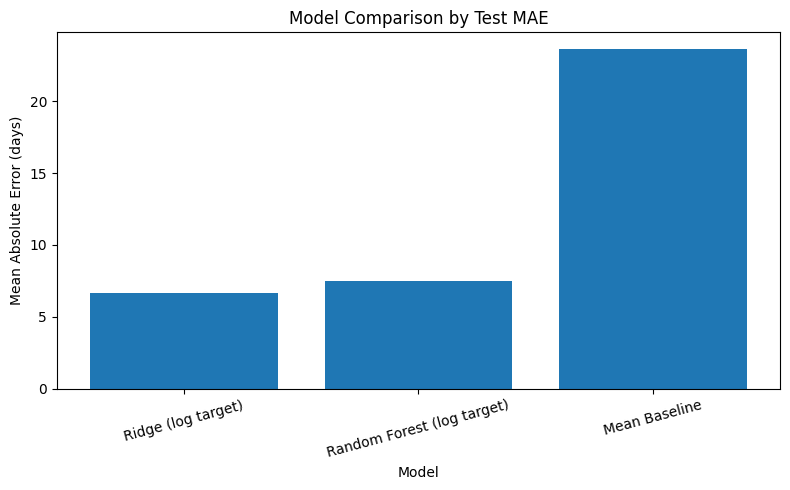

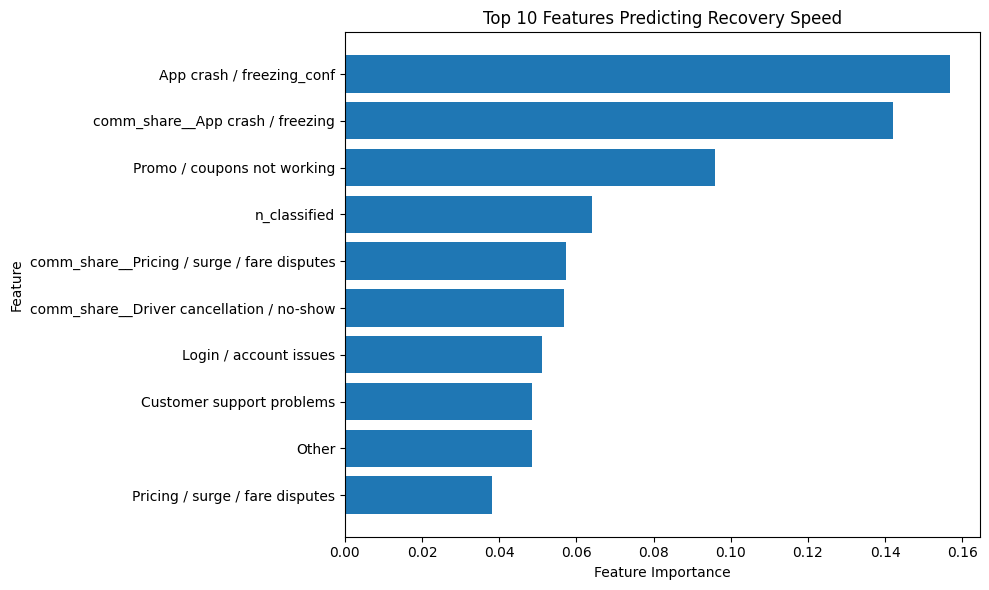

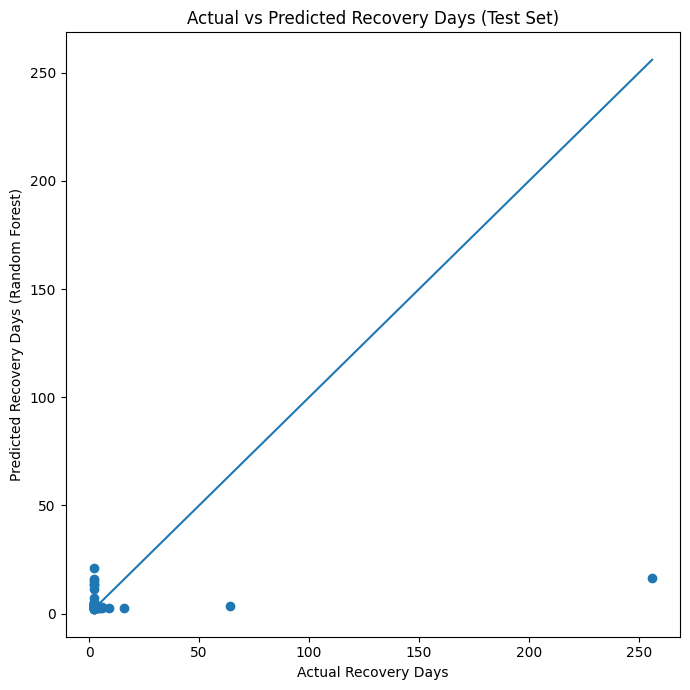

In [15]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

required_objs = ["results_df", "rf_importance", "pred_preview"]
missing = [x for x in required_objs if x not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}. Run the modeling cell first.")

model_col = "Model"
test_mae_col = "Test MAE (days)"
feature_col = "feature"
importance_col = "importance"
actual_col = "actual_recovery_days"
pred_col = "rf_pred"

plot_results = results_df.copy().sort_values(test_mae_col, ascending=True)
plt.figure(figsize=(8, 5))
plt.bar(plot_results[model_col], plot_results[test_mae_col])
plt.title("Model Comparison by Test MAE")
plt.ylabel("Mean Absolute Error (days)")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

rf_top = rf_importance.head(10).copy().sort_values(importance_col, ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(rf_top[feature_col], rf_top[importance_col])
plt.title("Top 10 Features Predicting Recovery Speed")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

plot_df = pred_preview.copy()
plt.figure(figsize=(7, 7))
plt.scatter(plot_df[actual_col], plot_df[pred_col])
plt.xlabel("Actual Recovery Days")
plt.ylabel("Predicted Recovery Days (Random Forest)")
plt.title("Actual vs Predicted Recovery Days (Test Set)")
min_val = min(plot_df[actual_col].min(), plot_df[pred_col].min())
max_val = max(plot_df[actual_col].max(), plot_df[pred_col].max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.tight_layout()
plt.show()


### Note on Censored Observations (Limitations)

Versions where the 7-day rolling average **never reaches the previous-version baseline**
are excluded from `model_df` (their `recovery_days` is `NaN`). These are **censored**
observations in the survival-analysis sense: we know recovery took *at least* N days
but do not know the true value.  Excluding them introduces **selection bias** toward
versions that recover quickly.  This is acknowledged explicitly in the Limitations section.
A future extension using survival regression (e.g. accelerated-failure-time models) would
handle censoring correctly.

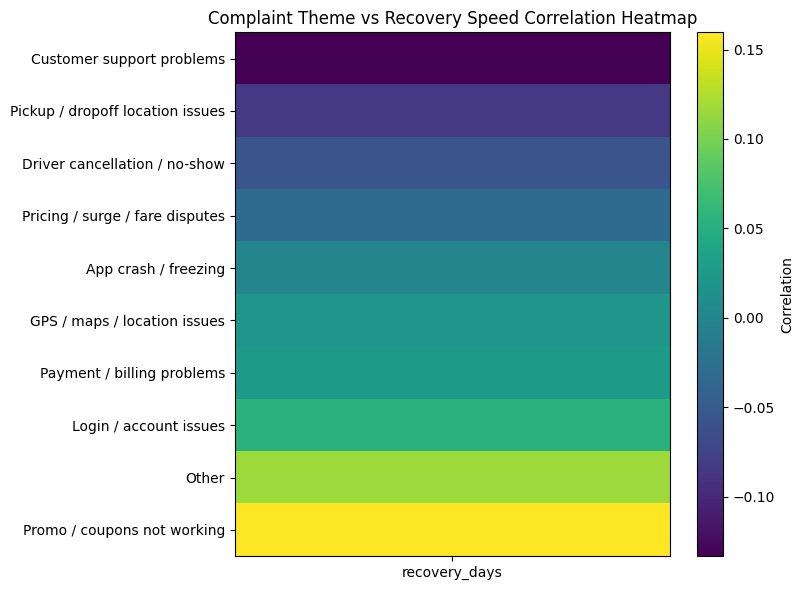

,recovery_days
Customer support problems,-0.133311
Pickup / dropoff location issues,-0.084169
Driver cancellation / no-show,-0.056016
Pricing / surge / fare disputes,-0.030840
App crash / freezing,0.000220
GPS / maps / location issues,0.018998
Payment / billing problems,0.026170
Login / account issues,0.053965
Other,0.116838
Promo / coupons not working,0.159659


In [16]:

import pandas as pd
import matplotlib.pyplot as plt

plot_df = MODEL_DF.copy()

theme_share_cols = [
    c for c in plot_df.columns
    if c not in [VERSION_COL, "start_day", "baseline_prev_version", "recovery_days", "n_classified"]
    and not c.endswith("_conf")
    and not c.startswith("comm_share__")
]

corr_df = plot_df[theme_share_cols + ["recovery_days"]].corr(numeric_only=True)
corr_target = corr_df[["recovery_days"]].drop(index="recovery_days").sort_values("recovery_days")

plt.figure(figsize=(8, 6))
plt.imshow(corr_target, aspect="auto")
plt.yticks(range(len(corr_target.index)), corr_target.index)
plt.xticks([0], ["recovery_days"])
plt.colorbar(label="Correlation")
plt.title("Complaint Theme vs Recovery Speed Correlation Heatmap")
plt.tight_layout()
plt.show()

display(corr_target)


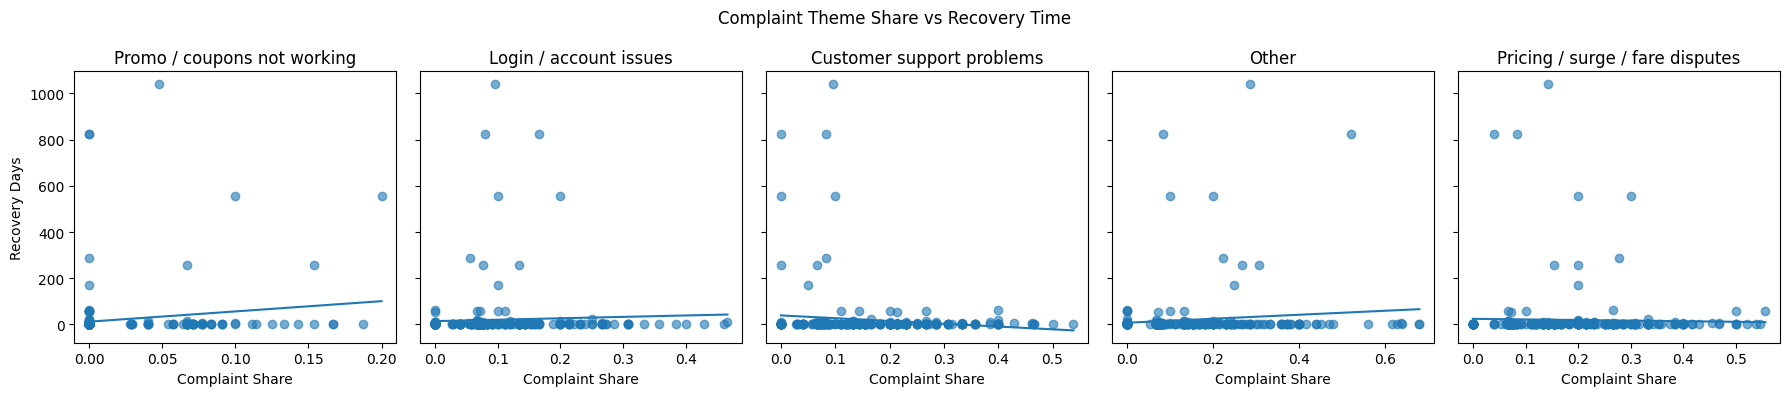

In [17]:

import matplotlib.pyplot as plt
import numpy as np

df_plot = MODEL_DF.copy()
theme_cols = [
    c for c in df_plot.columns
    if c not in [VERSION_COL, "start_day", "baseline_prev_version", "recovery_days", "n_classified"]
    and not c.endswith("_conf")
    and not c.startswith("comm_share__")
]

top_themes = RF_IMPORTANCE[RF_IMPORTANCE["feature"].isin(theme_cols)]["feature"].head(5).tolist()
fig, axes = plt.subplots(1, len(top_themes), figsize=(18, 4), sharey=True)
if len(top_themes) == 1:
    axes = [axes]
for i, theme in enumerate(top_themes):
    x = df_plot[theme]
    y = df_plot["recovery_days"]
    axes[i].scatter(x, y, alpha=0.6)
    if x.nunique() > 1:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        axes[i].plot(np.sort(x), p(np.sort(x)))
    axes[i].set_title(theme)
    axes[i].set_xlabel("Complaint Share")
axes[0].set_ylabel("Recovery Days")
plt.suptitle("Complaint Theme Share vs Recovery Time")
plt.tight_layout()
plt.show()


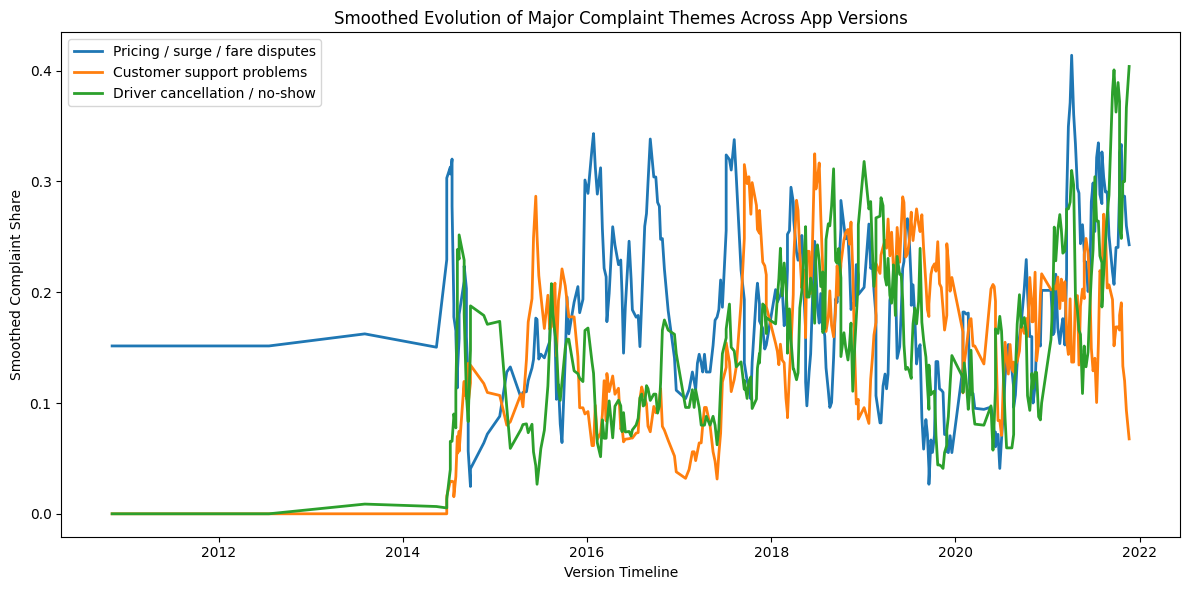

In [18]:

import matplotlib.pyplot as plt
import pandas as pd

df_plot = version_features.copy()
rec = recovery_df.copy()
df_plot[VERSION_COL] = pd.to_numeric(df_plot[VERSION_COL], errors="coerce")
rec[VERSION_COL] = pd.to_numeric(rec[VERSION_COL], errors="coerce")

theme_cols = [
    c for c in df_plot.columns
    if c not in [VERSION_COL, "n_classified"]
    and not c.endswith("_conf")
    and not c.startswith("comm_share__")
]
mean_shares = df_plot[theme_cols].mean().sort_values(ascending=False)
top_themes = [c for c in mean_shares.index if c != "Other"][:3]

timeline = df_plot.merge(rec[[VERSION_COL, "start_day"]], on=VERSION_COL, how="left").sort_values("start_day").copy()
for theme in top_themes:
    timeline[f"{theme}_smooth"] = timeline[theme].rolling(window=5, min_periods=1).mean()

plt.figure(figsize=(12, 6))
for theme in top_themes:
    plt.plot(timeline["start_day"], timeline[f"{theme}_smooth"], label=theme, linewidth=2)
plt.xlabel("Version Timeline")
plt.ylabel("Smoothed Complaint Share")
plt.title("Smoothed Evolution of Major Complaint Themes Across App Versions")
plt.legend()
plt.tight_layout()
plt.show()


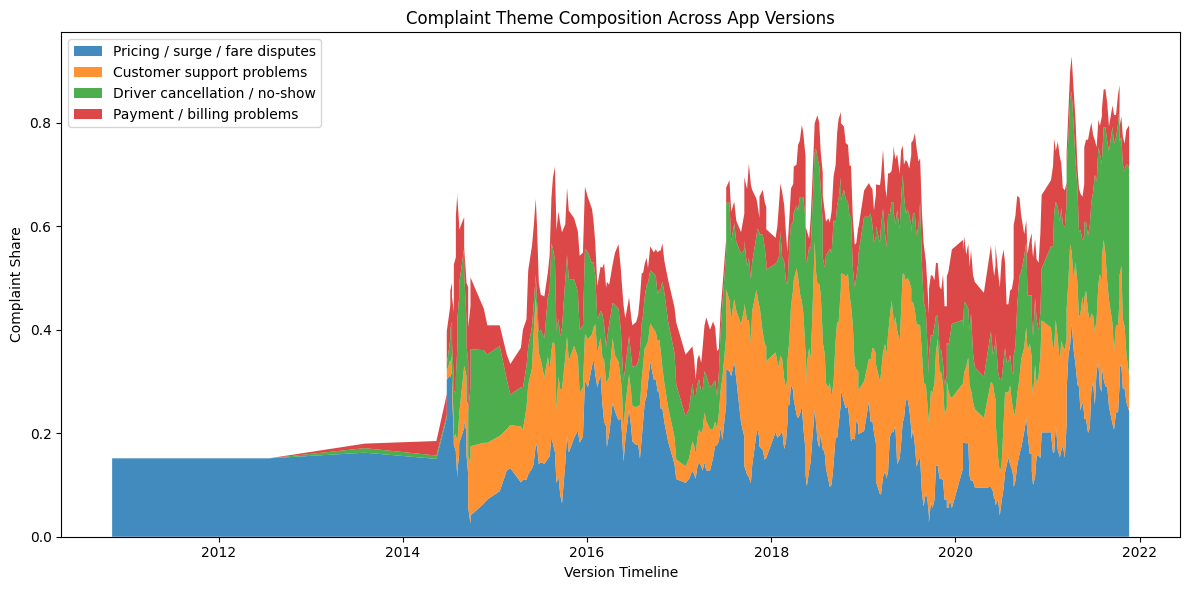

In [19]:

import matplotlib.pyplot as plt

df_plot = version_features.copy()
rec = recovery_df.copy()
df_plot[VERSION_COL] = pd.to_numeric(df_plot[VERSION_COL], errors="coerce")
rec[VERSION_COL] = pd.to_numeric(rec[VERSION_COL], errors="coerce")

theme_cols = [
    c for c in df_plot.columns
    if c not in [VERSION_COL, "n_classified"]
    and not c.endswith("_conf")
    and not c.startswith("comm_share__")
]
mean_shares = df_plot[theme_cols].mean().sort_values(ascending=False)
top_themes = [c for c in mean_shares.index if c != "Other"][:4]

timeline = df_plot.merge(rec[[VERSION_COL, "start_day"]], on=VERSION_COL, how="left").sort_values("start_day").copy()
for theme in top_themes:
    timeline[theme] = timeline[theme].rolling(window=5, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.stackplot(timeline["start_day"], [timeline[t] for t in top_themes], labels=top_themes, alpha=0.85)
plt.xlabel("Version Timeline")
plt.ylabel("Complaint Share")
plt.title("Complaint Theme Composition Across App Versions")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


/tmp/ipykernel_2277/147000544.py:46: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


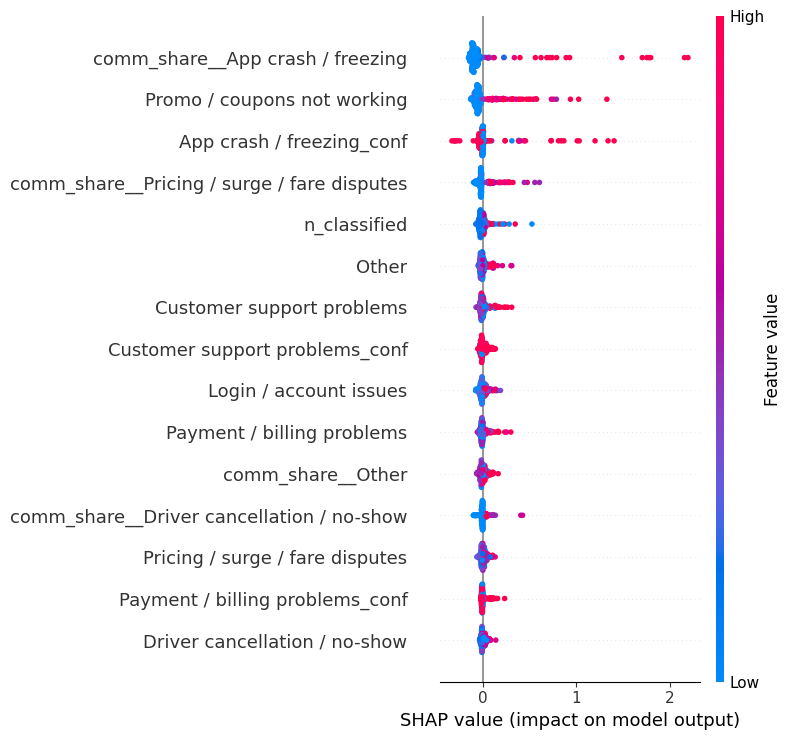

In [20]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.impute import SimpleImputer

non_feature_cols = [VERSION_COL, "start_day", "baseline_prev_version", "recovery_days"]
feature_cols = [c for c in MODEL_DF.columns if c not in non_feature_cols]

X = MODEL_DF[feature_cols].copy()

# Match training-time imputation
imp = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imp.fit_transform(X), columns=feature_cols, index=X.index)

# If rf_pipe has a preprocessing step, transform X the same way before SHAP
if "preprocess" in rf_pipe.named_steps:
    X_for_shap = rf_pipe.named_steps["preprocess"].transform(X_imp)
    rf_estimator = rf_pipe.named_steps["model"]

    # recover feature names after preprocessing if possible
    try:
        shap_feature_names = rf_pipe.named_steps["preprocess"].get_feature_names_out()
    except Exception:
        shap_feature_names = [f"feature_{i}" for i in range(X_for_shap.shape[1])]

    explainer = shap.TreeExplainer(rf_estimator)
    shap_values = explainer.shap_values(X_for_shap, check_additivity=False)

    shap.summary_plot(
        shap_values,
        X_for_shap,
        feature_names=shap_feature_names,
        max_display=15,
        show=False
    )
    plt.tight_layout()
    plt.show()

else:
    # No preprocessing step inside the pipeline
    rf_estimator = rf_pipe.named_steps["model"]

    explainer = shap.TreeExplainer(rf_estimator)
    shap_values = explainer.shap_values(X_imp, check_additivity=False)

    shap.summary_plot(
        shap_values,
        X_imp,
        feature_names=feature_cols,
        max_display=15,
        show=False
    )
    plt.tight_layout()
    plt.show()